# 05 Connected-Component Post-Processing Comparison

This notebook evaluates whether validation-tuned connected-component filtering improves crack segmentation predictions.

The important methodological constraint is that the minimum component area is selected on the validation split only. After that, the selected rule is fixed and evaluated once on the test split. This avoids using the test set to tune a post-processing hyperparameter.

Research question:

Can an explanation-guided rule, removing small isolated predicted crack components, reduce false positives without harming recall too much?

## Method Summary

1. Load a trained segmentation model checkpoint.
2. Predict masks on the validation and test splits using a fixed probability threshold.
3. Sweep candidate `min_component_area` values on validation predictions.
4. Select the value that maximizes the validation metric, usually `mean_f1`.
5. Apply the selected value to the test predictions.
6. Compare test metrics before and after post-processing.

Interpretation:

- If precision improves and FP pixels decrease, the filter is removing false-positive fragments.
- If recall drops sharply or FN pixels increase a lot, the filter is also removing real thin cracks.
- If F1/IoU improves, the explanation-guided filtering rule is useful for this model and setting.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('/users/7/yu001011/csci5527/CSCI5527-final')
SUITE_DIR = PROJECT_ROOT / 'analysis' / 'explainability_suite'
SCRIPT_PATH = SUITE_DIR / 'postprocess_connected_components.py'
OUTPUT_DIR = SUITE_DIR / 'outputs' / 'postprocessing'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Use the project virtualenv when available. This avoids the system Python 3.6 issue.
VENV_PYTHON = Path('/users/7/yu001011/csci5527/.venv/bin/python')
PYTHON = VENV_PYTHON if VENV_PYTHON.exists() else Path(sys.executable)

print('Python:', PYTHON)
print('Script:', SCRIPT_PATH)
print('Output:', OUTPUT_DIR)

Python: /users/7/yu001011/csci5527/.venv/bin/python
Script: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/postprocess_connected_components.py
Output: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/postprocessing


In [2]:
# Models already used by the explainability suite.
MODEL_NAMES = [
    'Unet-resnet34-imagenet_Single-TB',
    'Unet-efficientnet-b0-imagenet_Single-TB',
]

# Keep threshold fixed here. Do not choose this value from test performance.
THRESHOLD = 0.50

# Candidate component areas are tuned on validation only by the script.
MIN_AREAS = '0,5,10,20,30,50,75,100,150,200,300,500'
SELECTION_METRIC = 'mean_f1'
BATCH_SIZE = 4
IMG_SIZE = 512

MODEL_NAMES

['Unet-resnet34-imagenet_Single-TB', 'Unet-efficientnet-b0-imagenet_Single-TB']

## Run Post-Processing Sweep

Run the next cell to generate validation sweep files and test comparison files.

Expected outputs per model:

- `connected_components_<model>_thr0p5_val_sweep.csv`
- `connected_components_<model>_thr0p5_test_summary.csv`
- `connected_components_<model>_thr0p5_test_per_image_raw.csv`
- `connected_components_<model>_thr0p5_test_per_image_selected.csv`
- `connected_components_<model>_thr0p5_metadata.json`

In [3]:
def run_postprocess(model_name: str):
    cmd = [
        str(PYTHON),
        str(SCRIPT_PATH),
        '--project-root', str(PROJECT_ROOT),
        '--model-name', model_name,
        '--threshold', str(THRESHOLD),
        '--min-areas', MIN_AREAS,
        '--selection-metric', SELECTION_METRIC,
        '--batch-size', str(BATCH_SIZE),
        '--img-size', str(IMG_SIZE),
        '--output-dir', str(OUTPUT_DIR),
    ]
    print('\nRunning:', model_name)
    print(' '.join(cmd))
    completed = subprocess.run(cmd, cwd=PROJECT_ROOT, text=True, capture_output=True)
    print(completed.stdout)
    if completed.returncode != 0:
        print(completed.stderr)
        raise RuntimeError(f'postprocess failed for {model_name}')


for model_name in MODEL_NAMES:
    run_postprocess(model_name)


Running: Unet-resnet34-imagenet_Single-TB
/users/7/yu001011/csci5527/.venv/bin/python /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/postprocess_connected_components.py --project-root /users/7/yu001011/csci5527/CSCI5527-final --model-name Unet-resnet34-imagenet_Single-TB --threshold 0.5 --min-areas 0,5,10,20,30,50,75,100,150,200,300,500 --selection-metric mean_f1 --batch-size 4 --img-size 512 --output-dir /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/postprocessing
device = cuda:0
model = Unet-resnet34-imagenet_Single-TB
setting = Single-TB
Loading CSV metadata...
Sanitizing training and validation masks...
Sanitizing test masks...
Generating Dataloaders...

Pipeline Ready:
 - Training batches: 82
 - Validation batches: 24
 - Testing batches: 12
Predicting validation split...
Predicting test split...

Validation-selected post-processing
selected min_component_area = 300
validation mean_f1 = 0.7256

Test summary
               

## Load Test Summary

The `test_summary` file has two rows:

- `postprocess = none`: raw prediction at threshold 0.5
- `postprocess = remove_small_components`: prediction after validation-selected component filtering

In [4]:
def threshold_tag(threshold: float) -> str:
    return str(threshold).replace('.', 'p')


def result_prefix(model_name: str) -> Path:
    return OUTPUT_DIR / f"connected_components_{model_name}_thr{threshold_tag(THRESHOLD)}"


summary_frames = []
metadata_rows = []

for model_name in MODEL_NAMES:
    prefix = result_prefix(model_name)
    summary_path = prefix.with_name(prefix.name + '_test_summary.csv')
    metadata_path = prefix.with_name(prefix.name + '_metadata.json')
    if not summary_path.exists():
        print('Missing:', summary_path)
        continue

    summary = pd.read_csv(summary_path)
    summary.insert(0, 'model_name', model_name)
    summary_frames.append(summary)

    if metadata_path.exists():
        metadata = json.loads(metadata_path.read_text())
        metadata_rows.append({
            'model_name': model_name,
            'selected_min_component_area': metadata.get('selected_min_component_area'),
            'selection_metric': metadata.get('selection_metric'),
            'threshold': metadata.get('threshold'),
            'note': metadata.get('note'),
        })

test_summary = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
metadata_df = pd.DataFrame(metadata_rows)

display(metadata_df)
display(test_summary)

,model_name,selected_min_component_area,selection_metric,threshold,note
0,Unet-resnet34-imagenet_Single-TB,300,mean_f1,0.5,min_component_area selected on validation spli...
1,Unet-efficientnet-b0-imagenet_Single-TB,300,mean_f1,0.5,min_component_area selected on validation spli...


,model_name,postprocess,n_images,mean_iou,mean_f1,mean_precision,mean_recall,micro_iou,micro_f1,micro_precision,micro_recall,tp_pixels,fp_pixels,fn_pixels,empty_gt_with_prediction,positive_gt_empty_prediction,split,min_component_area
0,Unet-resnet34-imagenet_Single-TB,none,48,0.346191,0.405696,0.490465,0.717019,0.409812,0.581371,0.579554,0.583199,20307,14732,14513,13,4,test,0
1,Unet-resnet34-imagenet_Single-TB,remove_small_components,48,0.568479,0.612072,0.847137,0.631192,0.409321,0.580877,0.695577,0.498650,17363,7599,17457,1,10,test,300
2,Unet-efficientnet-b0-imagenet_Single-TB,none,48,0.211393,0.270716,0.328434,0.667285,0.269414,0.424470,0.487735,0.375732,13083,13741,21737,19,1,test,0
3,Unet-efficientnet-b0-imagenet_Single-TB,remove_small_components,48,0.517515,0.556829,0.857475,0.580480,0.232074,0.376720,0.624850,0.269644,9389,5637,25431,2,12,test,300


In [5]:
def make_delta_table(test_summary: pd.DataFrame) -> pd.DataFrame:
    rows = []
    metrics = [
        'mean_iou', 'mean_f1', 'mean_precision', 'mean_recall',
        'micro_iou', 'micro_f1', 'micro_precision', 'micro_recall',
        'tp_pixels', 'fp_pixels', 'fn_pixels',
    ]
    for model_name, group in test_summary.groupby('model_name'):
        raw = group[group['postprocess'] == 'none']
        pp = group[group['postprocess'] == 'remove_small_components']
        if raw.empty or pp.empty:
            continue
        raw = raw.iloc[0]
        pp = pp.iloc[0]
        row = {'model_name': model_name}
        for metric in metrics:
            if metric in group.columns:
                row[f'{metric}_raw'] = raw[metric]
                row[f'{metric}_postprocessed'] = pp[metric]
                row[f'{metric}_delta'] = pp[metric] - raw[metric]
        rows.append(row)
    return pd.DataFrame(rows)


delta_table = make_delta_table(test_summary)
delta_path = OUTPUT_DIR / 'connected_components_test_summary_delta.csv'
delta_table.to_csv(delta_path, index=False)
print('Saved:', delta_path)
display(delta_table)

Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/postprocessing/connected_components_test_summary_delta.csv


,model_name,mean_iou_raw,mean_iou_postprocessed,mean_iou_delta,mean_f1_raw,mean_f1_postprocessed,mean_f1_delta,mean_precision_raw,mean_precision_postprocessed,mean_precision_delta,...,micro_recall_delta,tp_pixels_raw,tp_pixels_postprocessed,tp_pixels_delta,fp_pixels_raw,fp_pixels_postprocessed,fp_pixels_delta,fn_pixels_raw,fn_pixels_postprocessed,fn_pixels_delta
0,Unet-efficientnet-b0-imagenet_Single-TB,0.211393,0.517515,0.306122,0.270716,0.556829,0.286113,0.328434,0.857475,0.529041,...,-0.106088,13083,9389,-3694,13741,5637,-8104,21737,25431,3694
1,Unet-resnet34-imagenet_Single-TB,0.346191,0.568479,0.222288,0.405696,0.612072,0.206376,0.490465,0.847137,0.356672,...,-0.084549,20307,17363,-2944,14732,7599,-7133,14513,17457,2944


## Visualization

These plots are meant for presentation slides. The first shows whether F1 improves. The second shows the FP/FN tradeoff.

Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/postprocessing/fig_connected_components_micro_f1_comparison.png


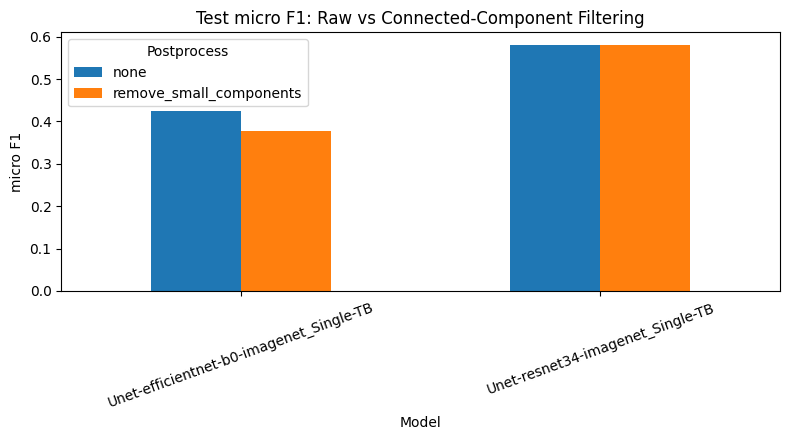

In [6]:
if not test_summary.empty:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_df = test_summary.pivot(index='model_name', columns='postprocess', values='micro_f1')
    plot_df = plot_df[['none', 'remove_small_components']]
    plot_df.plot(kind='bar', ax=ax)
    ax.set_title('Test micro F1: Raw vs Connected-Component Filtering')
    ax.set_xlabel('Model')
    ax.set_ylabel('micro F1')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Postprocess')
    fig.tight_layout()
    fig_path = OUTPUT_DIR / 'fig_connected_components_micro_f1_comparison.png'
    fig.savefig(fig_path, dpi=180)
    print('Saved:', fig_path)
    plt.show()

Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/postprocessing/fig_connected_components_fp_fn_delta.png


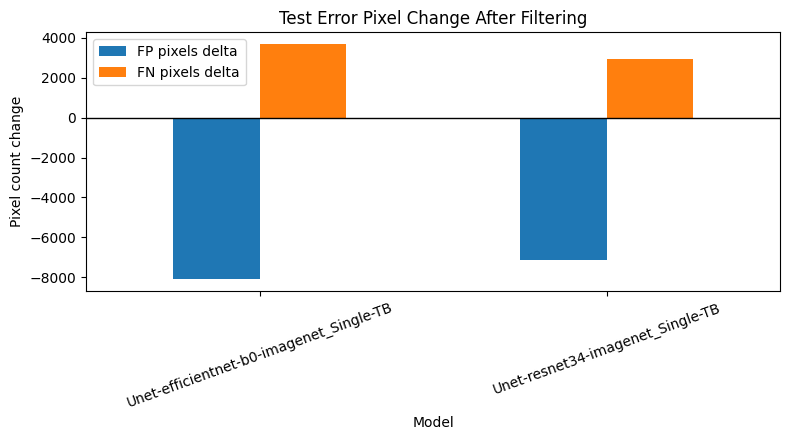

In [7]:
if not delta_table.empty:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    fp_delta = delta_table.set_index('model_name')['fp_pixels_delta']
    fn_delta = delta_table.set_index('model_name')['fn_pixels_delta']
    pd.DataFrame({'FP pixels delta': fp_delta, 'FN pixels delta': fn_delta}).plot(kind='bar', ax=ax)
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title('Test Error Pixel Change After Filtering')
    ax.set_xlabel('Model')
    ax.set_ylabel('Pixel count change')
    ax.tick_params(axis='x', rotation=20)
    fig.tight_layout()
    fig_path = OUTPUT_DIR / 'fig_connected_components_fp_fn_delta.png'
    fig.savefig(fig_path, dpi=180)
    print('Saved:', fig_path)
    plt.show()

## Validation Sweep

Use this section to inspect which `min_component_area` was selected and whether the validation curve is stable. A stable curve is more convincing than a single sharp lucky peak.

In [8]:
val_sweeps = []
for model_name in MODEL_NAMES:
    prefix = result_prefix(model_name)
    val_path = prefix.with_name(prefix.name + '_val_sweep.csv')
    if not val_path.exists():
        continue
    val = pd.read_csv(val_path)
    val.insert(0, 'model_name', model_name)
    val_sweeps.append(val)

val_sweep = pd.concat(val_sweeps, ignore_index=True) if val_sweeps else pd.DataFrame()
display(val_sweep.head(20))

,model_name,n_images,mean_iou,mean_f1,mean_precision,mean_recall,micro_iou,micro_f1,micro_precision,micro_recall,tp_pixels,fp_pixels,fn_pixels,empty_gt_with_prediction,positive_gt_empty_prediction,split,min_component_area
0,Unet-resnet34-imagenet_Single-TB,94,0.669455,0.725615,0.829330,0.750775,0.486406,0.654473,0.672278,0.637587,41417,20190,23542,0,10,val,300
1,Unet-resnet34-imagenet_Single-TB,94,0.630503,0.689159,0.773602,0.766533,0.475963,0.644953,0.638903,0.651118,42296,23905,22663,4,8,val,200
2,Unet-resnet34-imagenet_Single-TB,94,0.638674,0.681459,0.884263,0.697393,0.457532,0.627817,0.705099,0.565803,36754,15372,28205,0,19,val,500
3,Unet-resnet34-imagenet_Single-TB,94,0.607381,0.669618,0.718059,0.785498,0.478363,0.647152,0.623619,0.672532,43687,26367,21272,7,5,val,150
4,Unet-resnet34-imagenet_Single-TB,94,0.532163,0.597019,0.626995,0.806814,0.478757,0.647513,0.609351,0.690774,44872,28767,20087,15,4,val,100
5,Unet-resnet34-imagenet_Single-TB,94,0.523314,0.589680,0.615565,0.812372,0.480108,0.648747,0.604215,0.700365,45495,29801,19464,16,4,val,75
6,Unet-resnet34-imagenet_Single-TB,94,0.480229,0.546937,0.570624,0.814722,0.474961,0.644032,0.593338,0.704198,45744,31352,19215,20,4,val,50
7,Unet-resnet34-imagenet_Single-TB,94,0.468885,0.535518,0.557686,0.816226,0.471300,0.640658,0.585129,0.707831,45980,32601,18979,21,4,val,30
8,Unet-resnet34-imagenet_Single-TB,94,0.468880,0.535391,0.545318,0.819416,0.470723,0.640125,0.580947,0.712726,46298,33396,18661,21,3,val,10
9,Unet-resnet34-imagenet_Single-TB,94,0.468520,0.535051,0.546013,0.817448,0.471024,0.640403,0.583013,0.710325,46142,33002,18817,21,3,val,20


Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/postprocessing/fig_connected_components_val_sweep_mean_f1.png


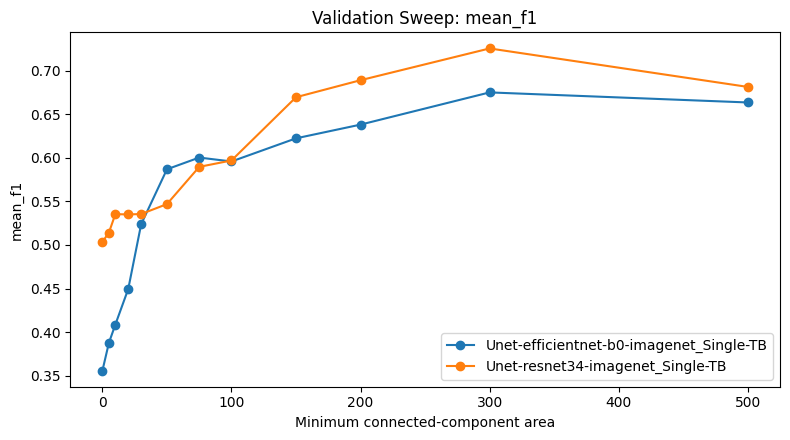

In [9]:
if not val_sweep.empty:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for model_name, group in val_sweep.groupby('model_name'):
        group = group.sort_values('min_component_area')
        ax.plot(group['min_component_area'], group[SELECTION_METRIC], marker='o', label=model_name)
    ax.set_title(f'Validation Sweep: {SELECTION_METRIC}')
    ax.set_xlabel('Minimum connected-component area')
    ax.set_ylabel(SELECTION_METRIC)
    ax.legend()
    fig.tight_layout()
    fig_path = OUTPUT_DIR / f'fig_connected_components_val_sweep_{SELECTION_METRIC}.png'
    fig.savefig(fig_path, dpi=180)
    print('Saved:', fig_path)
    plt.show()

## Per-Image Inspection

This table helps find examples where filtering helped or hurt the most. Positive `f1_delta` means the post-processing improved that image; negative `f1_delta` means it hurt that image.

In [10]:
per_image_rows = []

for model_name in MODEL_NAMES:
    prefix = result_prefix(model_name)
    raw_path = prefix.with_name(prefix.name + '_test_per_image_raw.csv')
    pp_path = prefix.with_name(prefix.name + '_test_per_image_selected.csv')
    if not raw_path.exists() or not pp_path.exists():
        continue
    raw = pd.read_csv(raw_path)
    pp = pd.read_csv(pp_path)
    merged = raw.merge(pp, on='sample_id', suffixes=('_raw', '_postprocessed'))
    merged.insert(0, 'model_name', model_name)
    merged['f1_delta'] = merged['f1_postprocessed'] - merged['f1_raw']
    merged['iou_delta'] = merged['iou_postprocessed'] - merged['iou_raw']
    merged['fp_pixels_delta'] = merged['fp_pixels_postprocessed'] - merged['fp_pixels_raw']
    merged['fn_pixels_delta'] = merged['fn_pixels_postprocessed'] - merged['fn_pixels_raw']
    per_image_rows.append(merged)

per_image_delta = pd.concat(per_image_rows, ignore_index=True) if per_image_rows else pd.DataFrame()
per_image_path = OUTPUT_DIR / 'connected_components_test_per_image_delta.csv'
if not per_image_delta.empty:
    per_image_delta.to_csv(per_image_path, index=False)
    print('Saved:', per_image_path)

display(per_image_delta.sort_values('f1_delta', ascending=False).head(10))
display(per_image_delta.sort_values('f1_delta', ascending=True).head(10))

Saved: /users/7/yu001011/csci5527/CSCI5527-final/analysis/explainability_suite/outputs/postprocessing/connected_components_test_per_image_delta.csv


,model_name,split_raw,sample_id,min_component_area_raw,gt_pixels_raw,raw_pred_pixels_raw,pred_pixels_raw,tp_pixels_raw,fp_pixels_raw,fn_pixels_raw,...,fp_pixels_postprocessed,fn_pixels_postprocessed,iou_postprocessed,f1_postprocessed,precision_postprocessed,recall_postprocessed,f1_delta,iou_delta,fp_pixels_delta,fn_pixels_delta
0,Unet-resnet34-imagenet_Single-TB,test,0,0,0,17,17,0,17,0,...,0,0,1.0,1.0,1.0,1.0,1.0,1.0,-17,0
23,Unet-resnet34-imagenet_Single-TB,test,23,0,0,161,161,0,161,0,...,0,0,1.0,1.0,1.0,1.0,1.0,1.0,-161,0
29,Unet-resnet34-imagenet_Single-TB,test,29,0,0,180,180,0,180,0,...,0,0,1.0,1.0,1.0,1.0,1.0,1.0,-180,0
31,Unet-resnet34-imagenet_Single-TB,test,31,0,0,24,24,0,24,0,...,0,0,1.0,1.0,1.0,1.0,1.0,1.0,-24,0
41,Unet-resnet34-imagenet_Single-TB,test,41,0,0,7,7,0,7,0,...,0,0,1.0,1.0,1.0,1.0,1.0,1.0,-7,0
44,Unet-resnet34-imagenet_Single-TB,test,44,0,0,451,451,0,451,0,...,0,0,1.0,1.0,1.0,1.0,1.0,1.0,-451,0
49,Unet-efficientnet-b0-imagenet_Single-TB,test,1,0,0,46,46,0,46,0,...,0,0,1.0,1.0,1.0,1.0,1.0,1.0,-46,0
50,Unet-efficientnet-b0-imagenet_Single-TB,test,2,0,0,76,76,0,76,0,...,0,0,1.0,1.0,1.0,1.0,1.0,1.0,-76,0
52,Unet-efficientnet-b0-imagenet_Single-TB,test,4,0,0,308,308,0,308,0,...,0,0,1.0,1.0,1.0,1.0,1.0,1.0,-308,0
61,Unet-efficientnet-b0-imagenet_Single-TB,test,13,0,0,54,54,0,54,0,...,0,0,1.0,1.0,1.0,1.0,1.0,1.0,-54,0


,model_name,split_raw,sample_id,min_component_area_raw,gt_pixels_raw,raw_pred_pixels_raw,pred_pixels_raw,tp_pixels_raw,fp_pixels_raw,fn_pixels_raw,...,fp_pixels_postprocessed,fn_pixels_postprocessed,iou_postprocessed,f1_postprocessed,precision_postprocessed,recall_postprocessed,f1_delta,iou_delta,fp_pixels_delta,fn_pixels_delta
16,Unet-resnet34-imagenet_Single-TB,test,16,0,296,405,405,193,212,103,...,0,296,0.000000,0.000000,1.000000,0.0000,-0.550642,-0.379921,-212,193
28,Unet-resnet34-imagenet_Single-TB,test,28,0,609,667,667,339,328,270,...,0,609,0.000000,0.000000,1.000000,0.0000,-0.531348,-0.361793,-328,339
93,Unet-efficientnet-b0-imagenet_Single-TB,test,45,0,490,333,333,212,121,278,...,0,490,0.000000,0.000000,1.000000,0.0000,-0.515188,-0.346972,-121,212
68,Unet-efficientnet-b0-imagenet_Single-TB,test,20,0,140,241,241,80,161,60,...,0,140,0.000000,0.000000,1.000000,0.0000,-0.419948,-0.265781,-161,80
86,Unet-efficientnet-b0-imagenet_Single-TB,test,38,0,436,379,379,166,213,270,...,0,436,0.000000,0.000000,1.000000,0.0000,-0.407362,-0.255778,-213,166
56,Unet-efficientnet-b0-imagenet_Single-TB,test,8,0,780,691,691,257,434,523,...,0,780,0.000000,0.000000,1.000000,0.0000,-0.349422,-0.211697,-434,257
87,Unet-efficientnet-b0-imagenet_Single-TB,test,39,0,199,94,94,50,44,149,...,0,199,0.000000,0.000000,1.000000,0.0000,-0.341297,-0.205761,-44,50
45,Unet-resnet34-imagenet_Single-TB,test,45,0,490,1252,1252,275,977,215,...,0,490,0.000000,0.000000,1.000000,0.0000,-0.315729,-0.187457,-977,275
58,Unet-efficientnet-b0-imagenet_Single-TB,test,10,0,2513,773,773,407,366,2106,...,0,2513,0.000000,0.000000,1.000000,0.0000,-0.247718,-0.141369,-366,407
90,Unet-efficientnet-b0-imagenet_Single-TB,test,42,0,1166,768,768,636,132,530,...,77,845,0.258246,0.410486,0.806533,0.2753,-0.247218,-0.231738,-55,315


## Report Template

You can adapt this wording for the final report or meeting slides:

> Based on the failure taxonomy, many false-positive crack predictions appear as small isolated connected components. To test whether this explanation can improve the model output, I applied connected-component post-processing. The minimum component area was tuned only on the validation split by sweeping candidate areas and selecting the best validation mean F1. The selected area threshold was then fixed and applied once to the test split. I compared raw predictions against post-processed predictions using IoU, F1, precision, recall, FP pixels, and FN pixels. This evaluates whether the explanation-guided rule reduces false positives without introducing too many false negatives.